In [4]:
!pip install insightface
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install opencv-python-headless matplotlib scikit-learn tqdm onnxruntime


Looking in indexes: https://download.pytorch.org/whl/cu118


In [1]:
!pip install insightface
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install opencv-python-headless matplotlib scikit-learn tqdm onnxruntime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 9.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 85.1 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp310-cp310-linux_x86_64.whl size=1055380 sha256=c5738c62eb3280c6523a064082f9f07cad9bc2af95789c10d8d70af620d6cf17
  Stored in directory: /root/.cache/pip/wheels/e3/d0/80/e3773fb8b6d1cca87ea1d33d9b1f20a223a6493c896da249b5
Successfully built insightface
Looking in indexes: https://download.pytorch.org/whl/cu118
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.2 MB/s eta 0:00:00


عکس خود را آپلود کنید:


Saving عکس.jpg to عکس (1).jpg


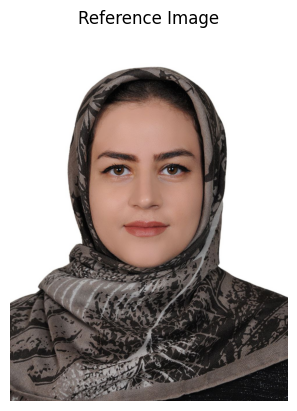

In [5]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# آپلود تصویر مرجع
print("عکس خود را آپلود کنید:")
uploaded = files.upload()
reference_image_path = list(uploaded.keys())[0]

# خواندن تصویر مرجع
reference_img = cv2.imread(reference_image_path)
reference_img = cv2.cvtColor(reference_img, cv2.COLOR_BGR2RGB)

# نمایش تصویر مرجع
plt.imshow(reference_img)
plt.title("Reference Image")
plt.axis('off')
plt.show()


In [6]:
from insightface.app import FaceAnalysis

# آماده‌سازی مدل
app = FaceAnalysis(name='buffalo_l')
app.prepare(ctx_id=-1)  # برای CPU مقدار -1 و برای GPU مقدار 0

# استخراج ویژگی چهره مرجع
reference_faces = app.get(reference_img)

if len(reference_faces) == 0:
    raise ValueError("هیچ چهره‌ای در تصویر مرجع یافت نشد.")
else:
    reference_face = reference_faces[0]
    reference_embedding = reference_face['embedding']  # بردار ویژگی چهره شما
    print("ویژگی‌های چهره مرجع استخراج شد.")


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
ویژگی‌های چه

عکس دسته‌جمعی خود را آپلود کنید:


Saving photo_2024-12-19_13-52-24.jpg to photo_2024-12-19_13-52-24.jpg


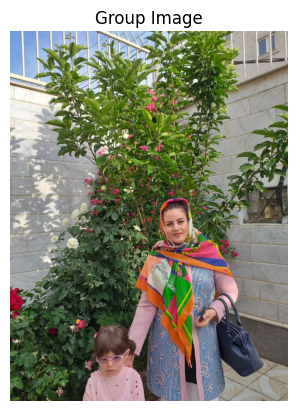

2 چهره در تصویر دسته‌جمعی شناسایی شد.


In [19]:
print("عکس دسته‌جمعی خود را آپلود کنید:")
uploaded = files.upload()
group_image_path = list(uploaded.keys())[0]

# خواندن تصویر دسته‌جمعی
group_img = cv2.imread(group_image_path)
group_img = cv2.cvtColor(group_img, cv2.COLOR_BGR2RGB)

# نمایش تصویر دسته‌جمعی
plt.imshow(group_img)
plt.title("Group Image")
plt.axis('off')
plt.show()

# استخراج چهره‌ها از تصویر دسته‌جمعی
group_faces = app.get(group_img)
print(f"{len(group_faces)} چهره در تصویر دسته‌جمعی شناسایی شد.")


چهره 1: شباهت = 61.26%
چهره 2: شباهت = 6.73%


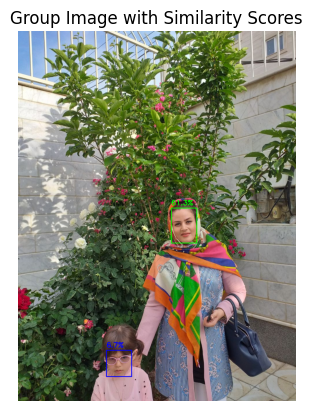

In [20]:
import numpy as np

# محاسبه شباهت کسینوسی
def cosine_similarity(embedding1, embedding2):
    return np.dot(embedding1, embedding2) / (np.linalg.norm(embedding1) * np.linalg.norm(embedding2))

# بررسی شباهت چهره‌ها
results = []
for i, face in enumerate(group_faces):
    group_embedding = face['embedding']
    similarity = cosine_similarity(reference_embedding, group_embedding)
    similarity_percentage = similarity * 100  # درصد شباهت

    # ذخیره نتیجه
    results.append((i, similarity_percentage, face['bbox']))
    print(f"چهره {i+1}: شباهت = {similarity_percentage:.2f}%")

# رسم جعبه‌ها روی چهره‌ها
for i, similarity_percentage, bbox in results:
    x1, y1, x2, y2 = map(int, bbox)
    label = f"{similarity_percentage:.1f}%"
    color = (0, 255, 0) if similarity_percentage > 50 else (0, 0, 255)  # سبز: شبیه، قرمز: متفاوت

    # رسم جعبه و برچسب
    cv2.rectangle(group_img, (x1, y1), (x2, y2), color, 2)
    cv2.putText(group_img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

# نمایش تصویر نهایی
plt.imshow(group_img)
plt.axis('off')
plt.title("Group Image with Similarity Scores")
plt.show()


In [21]:
output_path = 'group_with_scores.jpg'
cv2.imwrite(output_path, cv2.cvtColor(group_img, cv2.COLOR_RGB2BGR))

from google.colab import files
files.download(output_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>